# 퍼셉트론 실습

## 실습 순서

0. 사용할 라이브러리와 패키지 불러오기

1.   (데이터) 데이터 불러오기
2.  (데이터) 학습 데이터와 테스트 데이터 구분하기
3. (모델) 모델 구성하기
4. (모델 학습) 모델 학습하기
5. (모델 성능 평가) 모델 성능 평가하기
6. (결과) 모델 동작 시각화하기

## [실습 1] scikit-learn 라이브러리를 이용한 퍼셉트론



### 0. 사용할 라이브러리와 패키지 불러오기




In [2]:
# numpy, matplotlib을 각각 np, pl로 재지정해 불러온다.
# scikit-learn에서 사용할 패키지를 불러온다.
from sklearn.datasets import load_digits # 8x8 손글씨 숫자(0~9)데이터셋. 샘플 1797개, 64차원 벡터
from sklearn.linear_model import Perceptron # 퍼셉트론 선형분류기
from matplotlib import pyplot as plt # 시각화용
from sklearn.model_selection import train_test_split # 학습/테스트 데이터 분할
from sklearn.metrics import classification_report # 성능평가 도구들
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
import numpy as np # 수치계산

### 1. 데이터 불러오기



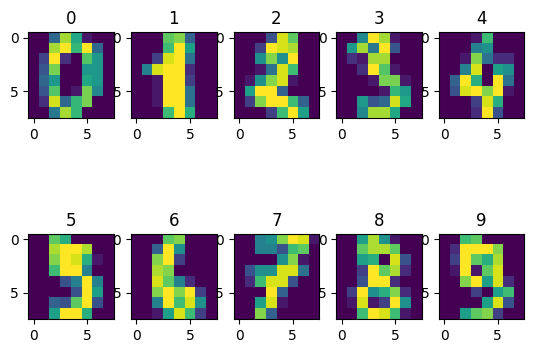

In [3]:
# 필기체 숫자 데이터셋을 불러온다.
# X: 1797개 샘플의 특징값(64차원 평탄화된 벡터), y: 정답 라벨 (0~9)
# return_X_y = True: 데이터와 타겟을 튜플로 받을 수 있음.
X, y = load_digits(return_X_y = True)

# 상단의 숫자는 실제값(y)를 의미하며, 이미지는 8x8 픽셀로 이루어진 입력 데이터를 의미한다.
rows = 2; cols = 5
fig = plt.figure()
for i in range(10):
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.imshow(X[i].reshape(8, 8))
    ax.set_title(str(y[i]))

### 2. 학습 데이터와 테스트 데이터 구분하기




In [4]:
# X(입력 데이터)와 y(실제값)을 학습 데이터셋과 테스트 데이터셋으로 분할한다. (학습:테스트 = 75:25)
# 실행할 때마다 split이 달라짐. 고정하고 싶으면 random_state=42 같은 고정값 추가
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

### 3. 모델 구성하기




In [6]:
# scikit-learn 라이브러리의 퍼셉트론 모델을 불러온다.
# Perceptron 기본 하이퍼파라미터로 실행.
# 학습 원리: 각 샘플을 보며 오분류 시 가중치를 업데이트하는 퍼셉트론 규칙(SGD 계열).
# 다중분류는 내부적으로 One-vs-Rest(OVR) 전략을 사용: 10개의 이진 분류기를 학습하여 점수가 가장 큰 클래스를 선택.
classifier = Perceptron()

### 4. 모델 학습하기




In [7]:
# fit 함수를 통해 모델을 학습한다.
# fit 함수에는 1) 가중치 초기화 2) 손실 함수 계산 3) 가중치 업데이트가 모두 구현되어 있다.
classifier.fit(X_train, y_train)
w = classifier.coef_ # 각 클래스별 64개의 가중치값
w_0 = classifier.intercept_ # 클래스별 절편값

### 5. 모델 성능 평가하기




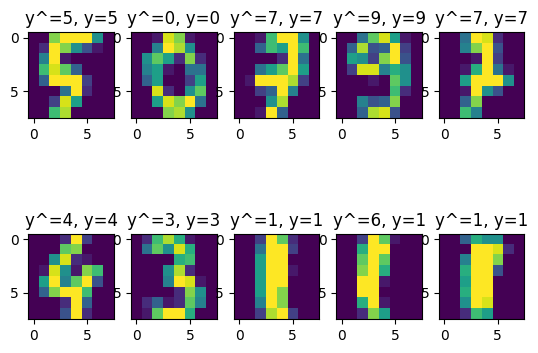

In [15]:
# predict 함수를 통해 테스트 데이터에 대해 퍼셉트론으로 얻은 예측값을 추출한다.
y_pred = classifier.predict(X_test)

# 학습 결과를 시각화한다.
rows = 2; cols = 5
fig = plt.figure()
for i in range(10):
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.imshow(X_test[i].reshape(8, 8))
    ax.set_title(f"y^={y_pred[i]}, y={y_test[i]}")
plt.show()

### 6. 모델 동작 시각화하기




              precision    recall  f1-score   support

     digit 0       1.00      0.98      0.99        49
     digit 1       0.74      1.00      0.85        43
     digit 2       0.95      0.98      0.96        42
     digit 3       0.98      0.96      0.97        46
     digit 4       0.95      0.90      0.92        41
     digit 5       0.92      0.97      0.95        36
     digit 6       0.88      0.96      0.92        54
     digit 7       0.98      0.98      0.98        44
     digit 8       0.97      0.67      0.79        51
     digit 9       0.98      0.91      0.94        44

    accuracy                           0.93       450
   macro avg       0.93      0.93      0.93       450
weighted avg       0.94      0.93      0.93       450



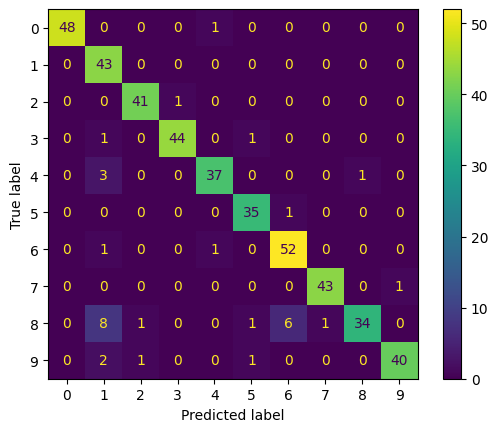

In [ ]:
# 혼동 행렬을 통해 성능을 확인한다.

# classification_report: 클래스별 precision, recall, f1-score, support 출력
# precision: 모델이 해당 클래스로 예측한 것 중 맞춘 비율
# recall: 실제 해당 클래스 중 맞춘 비율
# f1: precision과 recall의 조화평균
# support: 해당 클래스 실제 샘플 수
target_names = ['digit 0', 'digit 1', 'digit 2', 'digit 3', 'digit 4',
                'digit 5', 'digit 6', 'digit 7', 'digit 8', 'digit 9']
print(classification_report(y_test, y_pred, target_names = target_names))

# from_prediction()은 혼동행렬을 바로 그려줌. 대각선이 진할 수록 성능이 좋음
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

## [실습 2] 함수를 직접 정의해 구현한 퍼셉트론




### 1. 데이터 불러오기



In [17]:
# 필기체 숫자 데이터셋을 불러온다.
X, y = load_digits(return_X_y = True)

### 2. 학습 데이터와 테스트 데이터 구분하기




In [18]:
# X(입력 데이터)와 y(실제값)을 학습 데이터셋과 테스트 데이터셋으로 분할한다.
# 직접 구현에서는 10개의 숫자 분류가 아닌 이진 분류를 진행한다.
# 따라서 이에 맞는 형태의 데이터로의 변환이 필요하다.
# 특정 targetClass만 1, 나머지는 0으로 레이블링하여 데이터셋 split
def divideData(X, y, targetClass):
    idx = np.where(y == targetClass)[0]
    newY = np.zeros(len(y))
    newY[idx] = 1
    X_train, X_test, y_train, y_test = train_test_split(X, newY, test_size = 0.25, random_state = 42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = divideData(X, y, 3) # targetClass 3 => 1, 나머지 => 0

### 3. 모델 구성하기




In [37]:
# 퍼셉트론 모델 학습을 위해 필요한 다양한 함수들을 선언한다.
m, n = X_train.shape # m: 샘플수, n: 특징수
w = np.zeros((n, 1)) # 가중치 (bias 없음)
lr = 0.1 # 학습률
y_train = y_train.reshape(m, 1)

def sigmoid(x): # 시그모이드 함수 구현
		x = np.clip(x, -500, 500) # np.exp(-x)가 overflow 나지 않게 클리핑. np.exp(1000) => overflow
		return 1.0/(1 + np.exp(-x))

def BCE_loss(y, y_hat, eps=1e-15): # 이진 크로스 엔트로피 함수 구현
		y_hat = np.clip(y_hat, eps, 1 - eps) # np.log(0) => -inf. log 안정화
		loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
		return loss

def gradient_descent(X, y, y_hat): # 경사하강법 함수 구현
		global w
		dw = -(np.dot(X.T, (y - y_hat))) # X^T(y_hat-y)
		w -= lr*dw

### 4. 모델 학습하기




In [42]:
# 구현한 함수를 통해 모델을 학습한다.
# 이 함수에는 1) 예측 2) 손실 함수 계산 3) 경사하강기반 가중치 업데이트가 모두 구현되어 있다.
for epoch in range(100):
		y_hat = sigmoid(np.dot(X_train, w))
		loss = BCE_loss(y_train, y_hat)
		gradient_descent(X_train, y_train, y_hat)
print(w)

[[ 0.00000000e+00]
 [ 1.00897028e+01]
 [-2.08070858e+02]
 [-1.10660162e+01]
 [ 3.61089204e+02]
 [-9.78283125e+00]
 [-8.10839175e+01]
 [-2.07014434e+01]
 [-7.50006099e+00]
 [-5.98605341e+01]
 [ 1.41190358e+02]
 [-4.62951378e+01]
 [ 7.95934670e+01]
 [ 3.83302467e+02]
 [ 1.99029749e+02]
 [-2.11371767e+01]
 [ 2.50000000e-01]
 [-8.30058858e+01]
 [-4.91634129e+02]
 [-4.34026234e+02]
 [ 2.86247325e+02]
 [-3.10113713e+02]
 [-7.85372197e+01]
 [-1.30664655e+01]
 [-1.00000000e-01]
 [-2.46288532e+02]
 [-5.35194709e+02]
 [-3.79704453e+01]
 [-1.84947065e+00]
 [-4.40385510e+02]
 [-3.99149680e+02]
 [-1.50000000e-01]
 [ 0.00000000e+00]
 [-1.05170834e+02]
 [-2.39339456e+02]
 [-4.90453438e+00]
 [ 1.17264577e+02]
 [-6.32880503e+01]
 [-1.16888139e+02]
 [ 0.00000000e+00]
 [-7.50000000e-01]
 [ 6.32000866e+01]
 [-4.31507399e+02]
 [-7.93353470e+02]
 [ 1.26764975e+02]
 [ 3.77928717e+02]
 [ 4.35592438e+02]
 [-2.20000000e+00]
 [-6.00000000e-01]
 [-1.65970449e+01]
 [ 5.00780428e+01]
 [-2.12060841e+02]
 [-9.0492256

### 5. 모델 성능 평가하기




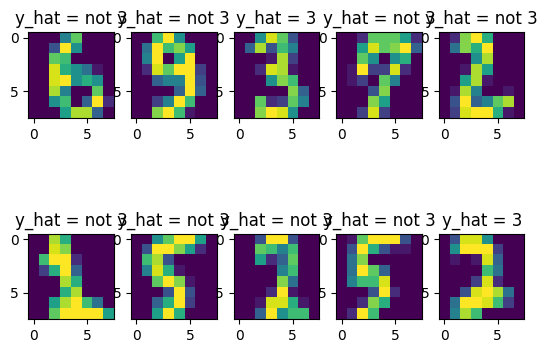

In [40]:
# predict 함수를 통해 퍼셉트론으로 얻은 예측값을 추출해 테스트 데이터로 평가한다.
def predict(X, w):
    preds = sigmoid(np.dot(X, w))
    pred_class = []
    pred_class = [1 if i > 0.5 else 0 for i in preds] # 0.5초과 1, 아니면 0
    return np.array(pred_class)
y_pred = predict(X_test, w)

# 학습 결과를 시각화한다.
rows = 2; cols = 5
fig = plt.figure()
for i in range(10):
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.imshow(X_test[i].reshape(8, 8))
    if y_pred[i] == 1:
        ax.set_title("y_hat = 3")
    else:
        ax.set_title("y_hat = not 3")
plt.show()

### 6. 모델 동작 시각화하기



              precision    recall  f1-score   support

     digit 3       1.00      0.99      0.99       404
      Others       0.90      0.96      0.93        46

    accuracy                           0.98       450
   macro avg       0.95      0.97      0.96       450
weighted avg       0.99      0.98      0.98       450



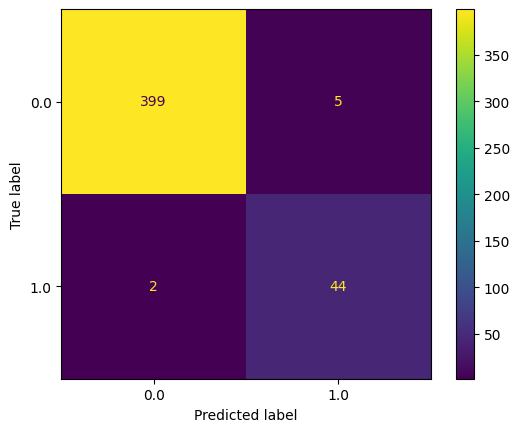

In [41]:
# 혼동 행렬을 통해 성능을 확인한다.
target_names = ['digit 3', 'Others']
print(classification_report(y_test, y_pred, target_names = target_names))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)